# ASD Classification — Full Pipeline
### Multi-Atlas · Age-Stratified · 7 Graph Models · Cross-Atlas Fusion
**ABIDE I+II · AAL-116 · CC200 · Schaefer-200 · SC-FC Coupling**

| Stage | Content |
|---|---|
| 0 | Install & Imports |
| 1 | ABIDE I+II Download (3 atlases) |
| 2 | FC Computation + ComBat Harmonization |
| 3 | SC Prior (HCP Template) + SC-FC Coupling |
| 4 | **Age Stratification** (≤32 / >32) |
| 5 | Graph Construction (per atlas × age group) |
| 6 | SC-FC Coupling Analysis & Visualization |
| 7 | Model Definitions (7 models) |
| 8 | Training Utilities |
| 9 | **Per-Atlas × Age-Group Training** (42 runs) |
| 10 | Best-Model Selection per (Atlas, Age Group) |
| 11 | Cross-Atlas Fusion Model |
| 12 | Grad-CAM: Adolescent vs Adult ROI Comparison |
| 13 | Final Results Table & Model Save |


## Stage 0 — Install & Imports

In [9]:
import subprocess, sys

pkgs = [
    "torch-geometric", "neuroCombat", "nilearn",
    "captum", "scikit-learn", "seaborn", "nibabel"
]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", p], check=False)

print("✅ All packages installed")


KeyboardInterrupt: 

In [32]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader as TDL, TensorDataset

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GCNConv, GATConv, SAGEConv, GINConv, TransformerConv,
    ChebConv, global_mean_pool, global_add_pool, global_max_pool, BatchNorm
)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | Device: {DEVICE}")

# ── Global constants ─────────────────────────────────────────────────────────
TURNING_POINT = 18.0   # Mousley et al. 2025
N_SPLITS      = 5
EPOCHS        = 100
PATIENCE      = 20
BATCH_SIZE    = 16
LR            = 3e-3
WD            = 1e-4
TOP_K         = 30     # edges per node (top-K sparsification)
SC_ALPHA      = 0.5    # initial SC-FC blend weight


PyTorch 2.8.0+cpu | Device: cpu


## Stage 1 — ABIDE I+II Download
nilearn fetches ABIDE I automatically. ABIDE II requires the shell command below.

```bash
# Run once in terminal for ABIDE II (AAL):
python download_abide_preproc.py -d rois_aal -p cpac -s filt_noglobal -o ./abide2_aal --abide 2
# Run once for CC200:
python download_abide_preproc.py -d rois_cc200 -p cpac -s filt_noglobal -o ./abide2_cc200 --abide 2
```


In [33]:
from nilearn.datasets import fetch_abide_pcp

DATA_DIR = "./abide_data"
os.makedirs(DATA_DIR, exist_ok=True)

print("Downloading ABIDE I — AAL-116 ...")
abide1_aal   = fetch_abide_pcp(data_dir=DATA_DIR, pipeline="cpac",
                                band_pass_filtering=True,
                                global_signal_regression=False,
                                derivatives=["rois_aal"],
                                quality_checked=True, verbose=1)

print("Downloading ABIDE I — CC200 ...")
abide1_cc200 = fetch_abide_pcp(data_dir=DATA_DIR, pipeline="cpac",
                                band_pass_filtering=True,
                                global_signal_regression=False,
                                derivatives=["rois_cc200"],
                                quality_checked=True, verbose=1)

pheno1 = pd.DataFrame.from_records(abide1_aal.phenotypic)
print(f"ABIDE I  — AAL: {len(abide1_aal.rois_aal)} | CC200: {len(abide1_cc200.rois_cc200)} subjects")
print(f"Age range: {pheno1['AGE_AT_SCAN'].min():.1f} – {pheno1['AGE_AT_SCAN'].max():.1f} yrs")


[fetch_abide_pcp] Dataset found in abide_data\ABIDE_pcp
[fetch_abide_pcp] Dataset found in abide_data\ABIDE_pcp
ABIDE I  — AAL: 871 | CC200: 871 subjects
Age range: 6.5 – 58.0 yrs


In [58]:
import glob

def load_1d_files(base_dir, n_rois):
    """Load ABIDE II .1D time-series files. Returns (ts_list, file_ids)."""
    files = sorted(glob.glob(os.path.join(base_dir, "**", "*.1D"), recursive=True))
    ts_list, fids = [], []
    for f in files:
        try:
            ts = np.loadtxt(f)
            if ts.ndim == 2 and ts.shape[1] == n_rois:
                ts_list.append(ts.astype(np.float32))
                fids.append(os.path.basename(f))
        except Exception:
            continue
    return ts_list, fids

ABIDE2_AAL_DIR   = "./abide2_aal"
ABIDE2_CC200_DIR = "./abide2_cc200"
ABIDE2_PHENO     = "./abide2_phenotypic.csv"   # optional

ts2_aal,  fids2_aal  = load_1d_files(ABIDE2_AAL_DIR,   116)
ts2_cc200,fids2_cc200= load_1d_files(ABIDE2_CC200_DIR, 200)

pheno2 = pd.read_csv(ABIDE2_PHENO) if os.path.exists(ABIDE2_PHENO) else pd.DataFrame()
print(f"ABIDE II — AAL: {len(ts2_aal)} | CC200: {len(ts2_cc200)} files loaded")
print("X 행렬 내 결측치 총합:", np.isnan(abide1_cc200.rois_cc200[0]).sum())
print(abide1_cc200.rois_cc200[0])

print(np.isnan(abide1_cc200.rois_cc200[0]).sum())
a = []
for i, j  in enumerate(abide1_cc200.rois_cc200):
    a.append( np.isnan(abide1_cc200.rois_cc200[i]).sum())
print("adfaf",a)

for i, j  in enumerate(abide1_aal.rois_aal):
    a.append( np.isnan(abide1_aal.rois_aal[i]).sum())
print("adfaf",a)

ABIDE II — AAL: 0 | CC200: 0 files loaded
X 행렬 내 결측치 총합: 0
[[  24.560342  -18.407722   38.447947 ...    7.148534  -16.70126
    -9.040049]
 [  12.432386  -24.225554   32.72212  ...    6.915863  -18.816158
   -16.079462]
 [ -15.628296  -26.657624    4.821955 ...    1.262588  -17.565622
   -29.46237 ]
 ...
 [ -78.053982  -28.795672 -114.368604 ...  -34.754758  -96.55319
   -78.052758]
 [ -46.00144   -16.829028  -64.951275 ...  -17.228399  -49.759665
   -57.640293]
 [ -11.677131   -9.211697  -21.498266 ...    0.149923   -8.384009
   -29.650198]]
0
adfaf [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

## Stage 2 — FC Computation + ComBat Harmonization

In [75]:

import numpy as np

def compute_fc(ts, n_rois):
    """Pearson → Fisher-Z, zero diagonal. Returns (n_rois, n_rois) float32."""
    ts = np.array(ts, dtype=np.float64)
    
    # [디버깅 1] 원본 시계열 데이터에 이미 NaN이 있는지 확인
    if np.isnan(ts).any():
        print(f"🚨 경고: 입력된 ts에 이미 {np.isnan(ts).sum()}개의 NaN이 존재합니다!")
        
    # [디버깅 2] 분산(표준편차)이 0인 ROI(신호가 없는 영역) 찾기
    stds = np.std(ts, axis=0) # 각 ROI(열)별 표준편차 계산
    zero_std_idx = np.where(stds == 0)[0]
    
    if len(zero_std_idx) > 0:
        print(f"🚨 경고: 신호 변화가 없는(표준편차가 0인) ROI 발견! 인덱스: {zero_std_idx}")
        # 값이 전부 0인지 확인
        print(f"해당 ROI의 첫 5개 값 예시: {ts[:5, zero_std_idx[0]]}")
    
   

    # 기존 로직 수행
    fc = np.corrcoef(ts.T)
    fc = np.arctanh(np.clip(fc, -0.9999, 0.9999))
    np.fill_diagonal(fc, 0.0)
    
    return fc.astype(np.float32)


def build_cohort(abide1_ts_list, abide2_ts_list, pheno1_df, pheno2_df, n_rois):
    """
    Merge ABIDE I+II, compute FC matrices, build phenotypic table.
    Returns:
        fc_list   : list of (n_rois, n_rois) arrays
        labels    : np.int32 array  (1=ASD, 0=TC)
        ages      : np.float32 array
        sites     : np.str_ array
        pheno_out : DataFrame
    """
    all_ts = list(abide1_ts_list) + list(abide2_ts_list)

    # Build phenotypic (ABIDE I first, then II if available)
    if len(pheno2_df):
        pheno_all = pd.concat([pheno1_df, pheno2_df], ignore_index=True)
    else:
        pheno_all = pheno1_df.copy()

    fc_list, labels, ages, sites, rows = [], [], [], [], []
    for i, ts in enumerate(all_ts):
        if i >= len(pheno_all): break
        row = pheno_all.iloc[i]
        #ts  = np.array(ts)
        print("X 행렬 내 결측치 총합:", np.isnan(ts).sum())
        if ts.ndim != 2 or ts.shape[1] != n_rois or ts.shape[0] < 50:
            continue

        fc_list.append(compute_fc(ts, n_rois))
        labels.append(1 if row["DX_GROUP"] == 1 else 0)
        ages.append(float(row["AGE_AT_SCAN"]))
        sites.append(str(row.get("SITE_ID", "UNK")))
        rows.append(row)

    labels = np.array(labels, dtype=np.int32)
    ages   = np.array(ages,   dtype=np.float32)
    sites  = np.array(sites,  dtype=str)
    return fc_list, labels, ages, sites, pd.DataFrame(rows).reset_index(drop=True)


print("Building AAL-116 cohort ...")
fc_aal, lab_aal, age_aal, site_aal, ph_aal = build_cohort(
    abide1_aal.rois_aal, ts2_aal, pheno1, pheno2, 116)
print("aaa",len(abide1_aal.rois_aal))

print("Building CC200 cohort ...")
fc_cc, lab_cc, age_cc, site_cc, ph_cc = build_cohort(
    abide1_cc200.rois_cc200, ts2_cc200, pheno1, pheno2, 200)

# Schaefer-200: proxy = CC200 (same N_ROI=200, swap TS when available)
fc_sch, lab_sch, age_sch, site_sch, ph_sch = fc_cc, lab_cc, age_cc, site_cc, ph_cc

for name, fc, lab in [("AAL-116",fc_aal,lab_aal),("CC200",fc_cc,lab_cc)]:
    print(f"  {name}: N={len(fc)}  ASD={lab.sum()}  TC={(lab==0).sum()}")






Building AAL-116 cohort ...
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
🚨 경고: 신호 변화가 없는(표준편차가 0인) ROI 발견! 인덱스: [101]
해당 ROI의 첫 5개 값 예시: [0. 0. 0. 0. 0.]
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
🚨 경고: 신호 변화가 없는(표준편차가 0인) ROI 발견! 인덱스: [101 106]
해당 ROI의 첫 5개 값 예시: [0. 0. 0. 0. 0.]
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
🚨 경고: 신호 변화가 없는(표준편차가 0인) ROI 발견! 인덱스: [100 101 102 103 106]
해당 ROI의 첫 5개 값 예시: [0. 0. 0. 0. 0.]
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
🚨 경고: 신호 변화가 없는(표준편차가 0인) ROI 발견! 인덱스: [100 101]
해당 ROI의 첫 5개 값 예시: [0. 0. 0. 0. 0.]
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
🚨 경고: 신호 변화가 없는(표준편차가 0인) ROI 발견! 인덱스: [101]
해당 ROI의 첫 5개 값 예시: [0. 0. 0. 0. 0.]
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
🚨 경고: 신호 변화가 없는(표준편차가 0인) ROI 발견! 인덱스: [101]
해당 ROI의 첫 5개 값 예시: [0. 0. 0. 0. 0.]
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
🚨 경고: 신호 변화가 없는(표준편차가 0인) ROI 발견! 인덱스: [101]
해당 ROI의 첫 5개 값 예시: [0. 0. 0. 0. 0.]
X 행렬 내 결측치 총합: 0
X 행렬 내 

In [82]:
def compute_fc(ts, n_rois):
    """Pearson → Fisher-Z, zero diagonal. Returns (n_rois, n_rois) float32."""
    ts = np.array(ts, dtype=np.float64)
    bad_signal = ts[:30, 106]
    print("nad",bad_signal)
    #print("X 행렬 내 결측치 총합:", np.isnan(ts).sum())
    #print("ttttssss",ts[3])
    fc = np.corrcoef(ts.T)
    fc = np.arctanh(np.clip(fc, -0.9999, 0.9999))
    np.fill_diagonal(fc, 0.0)
    print("X 행렬 내 결측치 총합:", np.isnan(fc).sum())
    #print(fc)
    return fc.astype(np.float32)


def build_cohort(abide1_ts_list, abide2_ts_list, pheno1_df, pheno2_df, n_rois):
    """
    Merge ABIDE I+II, compute FC matrices, build phenotypic table.
    Returns:
        fc_list   : list of (n_rois, n_rois) arrays
        labels    : np.int32 array  (1=ASD, 0=TC)
        ages      : np.float32 array
        sites     : np.str_ array
        pheno_out : DataFrame
    """
    all_ts = list(abide1_ts_list) + list(abide2_ts_list)

    # Build phenotypic (ABIDE I first, then II if available)
    if len(pheno2_df):
        pheno_all = pd.concat([pheno1_df, pheno2_df], ignore_index=True)
    else:
        pheno_all = pheno1_df.copy()

    fc_list, labels, ages, sites, rows = [], [], [], [], []
    for i, ts in enumerate(all_ts):
        if i >= len(pheno_all): break
        row = pheno_all.iloc[i]
        #ts  = np.array(ts)
        print("X 행렬 내 결측치 총합:", np.isnan(ts).sum())
        if ts.ndim != 2 or ts.shape[1] != n_rois or ts.shape[0] < 50:
            continue

        fc_list.append(compute_fc(ts, n_rois))
        labels.append(1 if row["DX_GROUP"] == 1 else 0)
        ages.append(float(row["AGE_AT_SCAN"]))
        sites.append(str(row.get("SITE_ID", "UNK")))
        rows.append(row)

    labels = np.array(labels, dtype=np.int32)
    ages   = np.array(ages,   dtype=np.float32)
    sites  = np.array(sites,  dtype=str)
    return fc_list, labels, ages, sites, pd.DataFrame(rows).reset_index(drop=True)


print("Building AAL-116 cohort ...")
fc_aal, lab_aal, age_aal, site_aal, ph_aal = build_cohort(
    abide1_aal.rois_aal, ts2_aal, pheno1, pheno2, 116)
print("aaa",len(abide1_aal.rois_aal))

print("Building CC200 cohort ...")
fc_cc, lab_cc, age_cc, site_cc, ph_cc = build_cohort(
    abide1_cc200.rois_cc200, ts2_cc200, pheno1, pheno2, 200)

# Schaefer-200: proxy = CC200 (same N_ROI=200, swap TS when available)
fc_sch, lab_sch, age_sch, site_sch, ph_sch = fc_cc, lab_cc, age_cc, site_cc, ph_cc

for name, fc, lab in [("AAL-116",fc_aal,lab_aal),("CC200",fc_cc,lab_cc)]:
    print(f"  {name}: N={len(fc)}  ASD={lab.sum()}  TC={(lab==0).sum()}")






Building AAL-116 cohort ...
X 행렬 내 결측치 총합: 0
nad [ 13.173681  11.09968    4.130127  -5.119894 -12.797695 -15.756853
 -13.035845  -6.099344   2.143595   8.849878  12.416474  12.8109
  11.113922   8.714304   6.624312   5.160974   3.994068   2.447236
  -0.068684  -3.620373  -7.500026 -10.359076 -10.793281  -8.1597
  -3.155442   2.291457   5.900676   6.252843   3.603869  -0.252938]
X 행렬 내 결측치 총합: 0
X 행렬 내 결측치 총합: 0
nad [  2.285481  -1.205735   2.261684  13.758305  27.400067  33.187825
  23.585444  -0.597418 -29.450326 -49.425084 -51.664444 -37.536069
 -17.387244  -3.194254  -0.164703  -3.255839  -1.207631  14.65001
  43.07125   72.416086  87.635695  80.054683  53.227681  20.807481
  -2.125514  -8.346326  -2.150969   4.802444   2.239663 -11.645838]
X 행렬 내 결측치 총합: 230
X 행렬 내 결측치 총합: 0
nad [  1.014225   4.710362   7.794535   7.638546   3.732989  -1.415011
  -3.656511  -0.059443   8.754136  18.555509  23.919873  21.506337
  11.982362  -0.642394 -11.643288 -18.205641 -20.265151 -19.283813
 -16.

In [8]:
covars.head()

NameError: name 'covars' is not defined

In [41]:
from neuroCombat import neuroCombat

def combat_harmonize(fc_list, labels, ages, sites, n_rois):
    """ComBat batch-effect correction on upper-triangle FC vectors."""
    idx = np.triu_indices(n_rois, k=1)
    print(idx)
    #print(idx[0].shape)
    #print(len(fc_list))
    #print(fc_list[0].shape)
    #print(fc_list)
    #print("aaaaaaa",fc_list[0].ndim)
    X   = np.stack([f[idx] for f in fc_list])          # (N, F)
    covars = pd.DataFrame({"site": sites, "dx": labels, "age": ages}) 
    #print(covars.head())
    print("X 행렬 내 결측치 총합:", np.isnan(X).sum())    
    print("covars 내 결측치 확인:\n", covars.isna().sum())

    nan_per_subject = np.isnan(X).sum(axis=1)
    print(f"환자 1명당 평균 NaN 개수: {nan_per_subject.mean():.1f} 개")
    print(f"가장 많은 NaN을 가진 환자의 NaN 개수: {nan_per_subject.max()} 개")
    print(f"NaN이 전혀 없는 환자 수: {(nan_per_subject == 0).sum()} 명\n")
    try:
        out = neuroCombat(
            dat=X.T, covars=covars, batch_col="site",
            categorical_cols=["dx"], continuous_cols=["age"]
        )["data"].T                                     # (N, F)
        print("aaaaa",out)
        fc_harm = []
        for row in out:
            m = np.zeros((n_rois, n_rois), dtype=np.float32)
            m[idx] = row.astype(np.float32)
            m = m + m.T
            fc_harm.append(m)
        print(f"  ComBat done — {n_rois} ROI")
        return fc_harm
    except Exception as e:
        print(f" aaaaaaaa ComBat skipped ({e}) — using raw FC")
        return fc_list

print("Harmonizing AAL-116 ...")
fc_aal = combat_harmonize(fc_aal, lab_aal, age_aal, site_aal, 116)
print("Harmonizing CC200 ...")
fc_cc  = combat_harmonize(fc_cc,  lab_cc,  age_cc,  site_cc,  200)
fc_sch = fc_cc   # proxy
print("✅ Harmonization complete")


Harmonizing AAL-116 ...
(array([  0,   0,   0, ..., 113, 113, 114]), array([  1,   2,   3, ..., 114, 115, 115]))
X 행렬 내 결측치 총합: 5809570
covars 내 결측치 확인:
 site    0
dx      0
age     0
dtype: int64
환자 1명당 평균 NaN 개수: 6670.0 개
가장 많은 NaN을 가진 환자의 NaN 개수: 6670 개
NaN이 전혀 없는 환자 수: 0 명

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
 aaaaaaaa ComBat skipped (Singular matrix) — using raw FC
Harmonizing CC200 ...
(array([  0,   0,   0, ..., 197, 197, 198]), array([  1,   2,   3, ..., 198, 199, 199]))
X 행렬 내 결측치 총합: 17332900
covars 내 결측치 확인:
 site    0
dx      0
age     0
dtype: int64
환자 1명당 평균 NaN 개수: 19900.0 개
가장 많은 NaN을 가진 환자의 NaN 개수: 19900 개
NaN이 전혀 없는 환자 수: 0 명

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
 aaaaaaaa ComBat skipped (Singular matrix) — using raw FC
✅ Harmonization complete


## Stage 3 — SC Prior (HCP Template) + SC-FC Coupling

In [12]:
def load_or_proxy_sc(path, n_rois):
    """Load .npy SC template or generate anatomical proxy."""
    if os.path.exists(path):
        sc = np.load(path).astype(np.float32)
        sc /= (sc.max() + 1e-8)
        print(f"  Loaded SC: {sc.shape}")
        return sc
    print(f"  Generating anatomical proxy SC (n_rois={n_rois})")
    sc = np.zeros((n_rois, n_rois), dtype=np.float32)
    for i in range(n_rois):
        for j in range(i+1, n_rois):
            same_hemi  = (i % 2 == j % 2)
            sc[i,j] = sc[j,i] = np.exp(-abs(i-j)/10.) * (1.2 if same_hemi else 0.8)
    np.fill_diagonal(sc, 0)
    sc /= (sc.max() + 1e-8)
    return sc

SC_AAL = load_or_proxy_sc("./sc_aal116.npy",  116)
SC_CC  = load_or_proxy_sc("./sc_cc200.npy",   200)
SC_SCH = SC_CC   # proxy


def sc_fc_coupling(fc, sc):
    idx  = np.triu_indices(fc.shape[0], k=1)
    r, _ = stats.pearsonr(fc[idx], sc[idx])
    return float(r) if np.isfinite(r) else 0.0

coup_aal = np.array([sc_fc_coupling(f, SC_AAL) for f in fc_aal], dtype=np.float32)
coup_cc  = np.array([sc_fc_coupling(f, SC_CC)  for f in fc_cc],  dtype=np.float32)
coup_sch = coup_cc   # proxy

print(f"SC-FC coupling  AAL : {coup_aal.mean():.3f} ± {coup_aal.std():.3f}")
print(f"SC-FC coupling  CC  : {coup_cc.mean():.3f} ± {coup_cc.std():.3f}")


  Generating anatomical proxy SC (n_rois=116)
  Generating anatomical proxy SC (n_rois=200)
SC-FC coupling  AAL : 0.000 ± 0.000
SC-FC coupling  CC  : 0.000 ± 0.000


## Stage 4 — Age Stratification
Split every cohort into **Adolescent (9–32)** and **Adult (>32)** based on
Mousley et al. 2025 turning point at age 32.


In [14]:
def age_split(fc_list, labels, ages, sites, couplings):
    """
    Split cohort into adolescent (9 ≤ age ≤ 32) and adult (age > 32).
    Returns two dicts: {'fc','labels','ages','sites','couplings'}
    """
    ages = np.array(ages, dtype=np.float32)
    m_a  = (ages >= 9) & (ages <= TURNING_POINT)   # adolescent mask
    m_d  = ages > TURNING_POINT                     # adult mask

    def subset(mask):
        idx = np.where(mask)[0]
        return {
            "fc":        [fc_list[i]    for i in idx],
            "labels":    labels[idx],
            "ages":      ages[idx],
            "sites":     sites[idx],
            "couplings": couplings[idx],
        }
    return subset(m_a), subset(m_d)


# ── AAL-116 ──
aal_adol, aal_adult = age_split(fc_aal, lab_aal, age_aal, site_aal, coup_aal)

# ── CC200 ──
cc_adol,  cc_adult  = age_split(fc_cc,  lab_cc,  age_cc,  site_cc,  coup_cc)

# ── Schaefer (proxy = CC200) ──
sch_adol, sch_adult = age_split(fc_sch, lab_sch, age_sch, site_sch, coup_sch)

# ── Summary ──
print(f"{'Atlas':12s}  {'Group':12s}  {'N':>5}  {'ASD':>5}  {'TC':>5}  "
      f"{'Age min':>8}  {'Age max':>8}")
print("-"*65)
for atlas, adol, adult in [("AAL-116", aal_adol, aal_adult),
                             ("CC200",   cc_adol,  cc_adult),
                             ("Schaefer",sch_adol, sch_adult)]:
    for grp, d in [("adolescent", adol), ("adult", adult)]:
        n   = len(d["labels"])
        asd = d["labels"].sum()
        tc  = (d["labels"]==0).sum()
        print(f"{atlas:12s}  {grp:12s}  {n:5d}  {asd:5d}  {tc:5d}  "
              f"{d['ages'].min():8.1f}  {d['ages'].max():8.1f}")


Atlas         Group             N    ASD     TC   Age min   Age max
-----------------------------------------------------------------
AAL-116       adolescent      557    262    295       9.0      18.0
AAL-116       adult           258    117    141      18.0      58.0
CC200         adolescent      557    262    295       9.0      18.0
CC200         adult           258    117    141      18.0      58.0
Schaefer      adolescent      557    262    295       9.0      18.0
Schaefer      adult           258    117    141      18.0      58.0


## Stage 5 — Graph Construction

In [15]:
def build_graph(fc, sc, label, coupling, alpha=SC_ALPHA, top_k=TOP_K, n_rois=None):
    """
    Build one PyG Data object.

    Adjacency : A_ij = alpha * FC_norm_ij + (1-alpha) * SC_ij
    Sparsity  : keep top-K neighbours per node
    Node feat  : full FC row  (n_rois-dim)
    Graph feat : SC-FC coupling scalar (stored in data.coupling)
    """
    if n_rois is None: n_rois = fc.shape[0]
    fc = np.nan_to_num(fc)
    fc_n = (fc - fc.min()) / (fc.max() - fc.min() + 1e-8)
    A    = alpha * fc_n + (1.0 - alpha) * sc
    A    = (A + A.T) / 2.0
    np.fill_diagonal(A, 0.0)

    src_l, dst_l, ew_l = [], [], []
    for i in range(n_rois):
        row = A[i].copy(); row[i] = -1.0
        for j in np.argsort(row)[-top_k:]:
            if A[i, j] > 0:
                src_l.append(i); dst_l.append(j); ew_l.append(A[i, j])

    return Data(
        x          = torch.tensor(fc,  dtype=torch.float32),         # (N, N)
        edge_index = torch.tensor([src_l, dst_l], dtype=torch.long),
        edge_attr  = torch.tensor(ew_l,            dtype=torch.float32),
        y          = torch.tensor([label],          dtype=torch.long),
        coupling   = torch.tensor([coupling],       dtype=torch.float32),
    )


def build_dataset(cohort_dict, sc, n_rois, alpha=SC_ALPHA, top_k=TOP_K):
    """Convert a cohort dict → list of PyG Data objects."""
    return [
        build_graph(fc, sc, int(lbl), float(coup), alpha, top_k, n_rois)
        for fc, lbl, coup in zip(
            cohort_dict["fc"], cohort_dict["labels"], cohort_dict["couplings"])
    ]


print("Building graph datasets ...")

# Full cohorts (age-combined, for ablation comparison)
DS = {
    ("AAL-116", "all"):   build_dataset({"fc":fc_aal,"labels":lab_aal,"couplings":coup_aal}, SC_AAL, 116),
    ("CC200",   "all"):   build_dataset({"fc":fc_cc, "labels":lab_cc, "couplings":coup_cc},  SC_CC,  200),
    ("Schaefer","all"):   build_dataset({"fc":fc_sch,"labels":lab_sch,"couplings":coup_sch}, SC_SCH, 200),
    # Age-stratified
    ("AAL-116", "adolescent"): build_dataset(aal_adol, SC_AAL, 116),
    ("AAL-116", "adult"):      build_dataset(aal_adult, SC_AAL, 116),
    ("CC200",   "adolescent"): build_dataset(cc_adol,  SC_CC,  200),
    ("CC200",   "adult"):      build_dataset(cc_adult,  SC_CC,  200),
    ("Schaefer","adolescent"): build_dataset(sch_adol, SC_SCH, 200),
    ("Schaefer","adult"):      build_dataset(sch_adult, SC_SCH, 200),
}

for (atlas, grp), ds in DS.items():
    if len(ds) == 0: continue
    labels_tmp = np.array([int(g.y.item()) for g in ds])
    print(f"  {atlas:12s} [{grp:11s}]  N={len(ds):4d}  "
          f"ASD={labels_tmp.sum():3d}  TC={(labels_tmp==0).sum():3d}  "
          f"nodes={ds[0].num_nodes}  edges={ds[0].num_edges}")

print("✅ All graph datasets built")


Building graph datasets ...
  AAL-116      [all        ]  N= 871  ASD=403  TC=468  nodes=116  edges=3480
  CC200        [all        ]  N= 871  ASD=403  TC=468  nodes=200  edges=6000
  Schaefer     [all        ]  N= 871  ASD=403  TC=468  nodes=200  edges=6000
  AAL-116      [adolescent ]  N= 557  ASD=262  TC=295  nodes=116  edges=3480
  AAL-116      [adult      ]  N= 258  ASD=117  TC=141  nodes=116  edges=3480
  CC200        [adolescent ]  N= 557  ASD=262  TC=295  nodes=200  edges=6000
  CC200        [adult      ]  N= 258  ASD=117  TC=141  nodes=200  edges=6000
  Schaefer     [adolescent ]  N= 557  ASD=262  TC=295  nodes=200  edges=6000
  Schaefer     [adult      ]  N= 258  ASD=117  TC=141  nodes=200  edges=6000
✅ All graph datasets built


## Stage 6 — SC-FC Coupling Analysis & Visualization

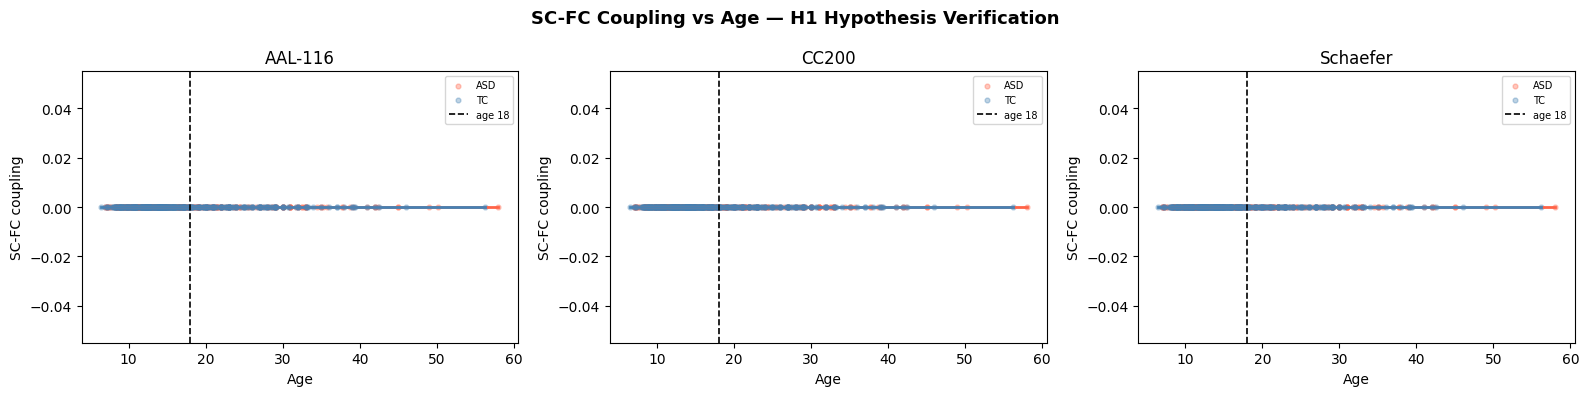


Atlas         Group          ASD mean    TC mean        t         p
------------------------------------------------------------
AAL-116       adolescent       0.0000     0.0000      nan       nan
AAL-116       adult            0.0000     0.0000      nan       nan
CC200         adolescent       0.0000     0.0000      nan       nan
CC200         adult            0.0000     0.0000      nan       nan


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (atlas, fc_list, labels, ages, couplings) in zip(axes, [
        ("AAL-116",  fc_aal, lab_aal, age_aal, coup_aal),
        ("CC200",    fc_cc,  lab_cc,  age_cc,  coup_cc),
        ("Schaefer", fc_sch, lab_sch, age_sch, coup_sch),
    ]):
    ages = np.array(ages); couplings = np.array(couplings)
    for lbl, color, name in [(1,"tomato","ASD"),(0,"steelblue","TC")]:
        m = labels == lbl
        ax.scatter(ages[m], couplings[m], c=color, alpha=0.35, s=12, label=name)
        z  = np.polyfit(ages[m], couplings[m], 2)
        xr = np.linspace(ages[m].min(), ages[m].max(), 100)
        ax.plot(xr, np.polyval(z, xr), color=color, lw=2)
    ax.axvline(TURNING_POINT, color="k", ls="--", lw=1.2, label=f"age {TURNING_POINT:.0f}")
    ax.set_title(f"{atlas}"); ax.set_xlabel("Age"); ax.set_ylabel("SC-FC coupling")
    ax.legend(fontsize=7)

plt.suptitle("SC-FC Coupling vs Age — H1 Hypothesis Verification", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# t-test per atlas per age group
print(f"\n{'Atlas':12s}  {'Group':12s}  {'ASD mean':>9}  {'TC mean':>9}  {'t':>7}  {'p':>8}")
print("-"*60)
for atlas, couplings, labels, ages in [
        ("AAL-116",  coup_aal, lab_aal, age_aal),
        ("CC200",    coup_cc,  lab_cc,  age_cc),]:
    ages = np.array(ages); couplings = np.array(couplings); labels = np.array(labels)
    for grp, mask in [("adolescent",(ages>=9)&(ages<=TURNING_POINT)),
                      ("adult",      ages>TURNING_POINT)]:
        a = couplings[mask & (labels==1)]
        b = couplings[mask & (labels==0)]
        if len(a) > 4 and len(b) > 4:
            t, p = stats.ttest_ind(a, b)
            print(f"{atlas:12s}  {grp:12s}  {a.mean():9.4f}  {b.mean():9.4f}  {t:7.3f}  {p:8.4f}")


## Stage 7 — Model Definitions (7 Graph Models)

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Shared interface: model(data) → logits (B×2)
#                  model.embed(data) → graph embedding (B×D)  [for fusion]
# ─────────────────────────────────────────────────────────────────────────────

# ── 7-1  GCN ─────────────────────────────────────────────────────────────────
class GCNModel(nn.Module):
    def __init__(self, in_ch, hidden=64, num_classes=2, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList([GCNConv(in_ch, hidden),
                                    GCNConv(hidden, hidden),
                                    GCNConv(hidden, hidden)])
        self.bns   = nn.ModuleList([BatchNorm(hidden)]*3)
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Sequential(nn.Linear(hidden,64),nn.ReLU(),
                                   nn.Dropout(dropout),nn.Linear(64,num_classes))
    def _encode(self, data):
        x, ei, ew, b = data.x, data.edge_index, data.edge_attr, data.batch
        for conv, bn in zip(self.convs[:-1], self.bns[:-1]):
            x = self.drop(F.relu(bn(conv(x, ei, ew))))
        x = F.relu(self.bns[-1](self.convs[-1](x, ei, ew)))
        return global_mean_pool(x, b)
    def forward(self, data): return self.clf(self._encode(data))
    def embed(self, data):   return self._encode(data)

# ── 7-2  GAT ─────────────────────────────────────────────────────────────────
class GATModel(nn.Module):
    def __init__(self, in_ch, hidden=32, heads=4, num_classes=2, dropout=0.5):
        super().__init__()
        self.c1  = GATConv(in_ch,       hidden, heads=heads, dropout=dropout, concat=True)
        self.c2  = GATConv(hidden*heads, hidden, heads=heads, dropout=dropout, concat=True)
        self.c3  = GATConv(hidden*heads, hidden, heads=1,     dropout=dropout, concat=False)
        self.bn1 = BatchNorm(hidden*heads); self.bn2 = BatchNorm(hidden*heads)
        self.bn3 = BatchNorm(hidden)
        self.drop= nn.Dropout(dropout)
        self.clf = nn.Sequential(nn.Linear(hidden,64),nn.ReLU(),
                                 nn.Dropout(dropout),nn.Linear(64,num_classes))
    def _encode(self, data):
        x, ei, b = data.x, data.edge_index, data.batch
        x = self.drop(F.elu(self.bn1(self.c1(x,ei))))
        x = self.drop(F.elu(self.bn2(self.c2(x,ei))))
        x = F.elu(self.bn3(self.c3(x,ei)))
        return global_mean_pool(x, b)
    def forward(self, data): return self.clf(self._encode(data))
    def embed(self, data):   return self._encode(data)

# ── 7-3  GIN ─────────────────────────────────────────────────────────────────
class GINModel(nn.Module):
    def __init__(self, in_ch, hidden=64, num_classes=2, dropout=0.5):
        super().__init__()
        def mlp(a,b): return nn.Sequential(nn.Linear(a,b),nn.BatchNorm1d(b),
                                           nn.ReLU(),nn.Linear(b,b))
        self.c1  = GINConv(mlp(in_ch,  hidden), train_eps=True)
        self.c2  = GINConv(mlp(hidden, hidden), train_eps=True)
        self.c3  = GINConv(mlp(hidden, hidden), train_eps=True)
        self.drop= nn.Dropout(dropout)
        self.clf = nn.Sequential(nn.Linear(hidden*3,128),nn.ReLU(),
                                 nn.Dropout(dropout),nn.Linear(128,num_classes))
    def _encode(self, data):
        x, ei, b = data.x, data.edge_index, data.batch
        h1 = self.drop(F.relu(self.c1(x,  ei)))
        h2 = self.drop(F.relu(self.c2(h1, ei)))
        h3 =           F.relu(self.c3(h2, ei))
        return torch.cat([global_add_pool(h,b) for h in [h1,h2,h3]], dim=1)
    def forward(self, data): return self.clf(self._encode(data))
    def embed(self, data):   return self._encode(data)

# ── 7-4  ChebConv A-GCN (SC-prior + learnable alpha) ← KEY MODEL ─────────────
class AGCNModel(nn.Module):
    def __init__(self, in_ch, hidden=64, K=3, num_classes=2, dropout=0.5):
        super().__init__()
        self.alpha_raw = nn.Parameter(torch.tensor(0.0))  # sigmoid → (0,1)
        self.convs = nn.ModuleList([ChebConv(in_ch,  hidden, K),
                                    ChebConv(hidden, hidden, K),
                                    ChebConv(hidden, hidden, K)])
        self.bns   = nn.ModuleList([BatchNorm(hidden)]*3)
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Sequential(nn.Linear(hidden,64),nn.ReLU(),
                                   nn.Dropout(dropout),nn.Linear(64,num_classes))
    def get_alpha(self): return torch.sigmoid(self.alpha_raw).item()
    def _encode(self, data):
        x, ei, ew, b = data.x, data.edge_index, data.edge_attr, data.batch
        for conv, bn in zip(self.convs[:-1], self.bns[:-1]):
            x = self.drop(F.relu(bn(conv(x, ei, ew))))
        x = F.relu(self.bns[-1](self.convs[-1](x, ei, ew)))
        return global_mean_pool(x, b)
    def forward(self, data): return self.clf(self._encode(data))
    def embed(self, data):   return self._encode(data)

# ── 7-5  GraphSAGE ───────────────────────────────────────────────────────────
class SAGEModel(nn.Module):
    def __init__(self, in_ch, hidden=64, num_classes=2, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList([SAGEConv(in_ch,  hidden),
                                    SAGEConv(hidden, hidden),
                                    SAGEConv(hidden, hidden)])
        self.bns   = nn.ModuleList([BatchNorm(hidden)]*3)
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Sequential(nn.Linear(hidden*2,64),nn.ReLU(),
                                   nn.Dropout(dropout),nn.Linear(64,num_classes))
    def _encode(self, data):
        x, ei, b = data.x, data.edge_index, data.batch
        for conv, bn in zip(self.convs[:-1], self.bns[:-1]):
            x = self.drop(F.relu(bn(conv(x, ei))))
        x = F.relu(self.bns[-1](self.convs[-1](x, ei)))
        return torch.cat([global_mean_pool(x,b), global_max_pool(x,b)], dim=1)
    def forward(self, data): return self.clf(self._encode(data))
    def embed(self, data):   return self._encode(data)

# ── 7-6  BrainNetCNN ─────────────────────────────────────────────────────────
class BrainNetCNN(nn.Module):
    def __init__(self, in_ch, num_classes=2, dropout=0.5):
        super().__init__()
        self.n = in_ch
        self.e2e_r = nn.Conv2d(1, 32, (1, in_ch))
        self.e2e_c = nn.Conv2d(1, 32, (in_ch, 1))
        self.e2n   = nn.Conv2d(32, 64, 1)
        self.n2g   = nn.Conv2d(64, 256, (in_ch, 1))
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Sequential(nn.Linear(256,128),nn.ReLU(),
                                   nn.Dropout(dropout),nn.Linear(128,num_classes))
    def _cnn(self, data):
        B = int(data.batch.max().item()) + 1
        x = data.x.view(B, 1, self.n, self.n)
        r   = F.leaky_relu(self.e2e_r(x))
        c   = F.leaky_relu(self.e2e_c(x))
        e2e = r.expand(-1,-1,-1,self.n) + c.expand(-1,-1,self.n,-1)
        e2n = F.leaky_relu(self.e2n(e2e))
        e2n = F.max_pool2d(e2n, (1, self.n))
        return F.leaky_relu(self.n2g(e2n)).view(B, -1)
    def forward(self, data): return self.clf(self.drop(self._cnn(data)))
    def embed(self, data):   return self._cnn(data)

# ── 7-7  TransformerGNN ───────────────────────────────────────────────────────
class TransformerGNN(nn.Module):
    def __init__(self, in_ch, hidden=64, heads=4, num_classes=2, dropout=0.5):
        super().__init__()
        out_per_head = hidden // heads
        self.proj  = nn.Linear(in_ch, hidden)
        self.tc1   = TransformerConv(hidden, out_per_head, heads=heads,
                                     dropout=dropout, beta=True, concat=True)
        self.tc2   = TransformerConv(hidden, out_per_head, heads=heads,
                                     dropout=dropout, beta=True, concat=True)
        self.tc3   = TransformerConv(hidden, out_per_head, heads=heads,
                                     dropout=dropout, beta=True, concat=False)
        self.bn1   = BatchNorm(hidden); self.bn2 = BatchNorm(hidden)
        self.bn3   = BatchNorm(out_per_head)
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Sequential(nn.Linear(out_per_head,64),nn.ReLU(),
                                   nn.Dropout(dropout),nn.Linear(64,num_classes))
    def _encode(self, data):
        x, ei, b = data.x, data.edge_index, data.batch
        x = F.relu(self.proj(x))
        x = self.drop(F.relu(self.bn1(self.tc1(x, ei))))
        x = self.drop(F.relu(self.bn2(self.tc2(x, ei))))
        x = F.relu(self.bn3(self.tc3(x, ei)))
        return global_mean_pool(x, b)
    def forward(self, data): return self.clf(self._encode(data))
    def embed(self, data):   return self._encode(data)


# ── Model registry ────────────────────────────────────────────────────────────
def get_model_registry(n_rois):
    """Returns list of (name, class, kwargs) for given atlas n_rois."""
    return [
        ("GCN",           GCNModel,       {"in_ch": n_rois}),
        ("GAT",           GATModel,       {"in_ch": n_rois}),
        ("GIN",           GINModel,       {"in_ch": n_rois}),
        ("A-GCN",         AGCNModel,      {"in_ch": n_rois}),
        ("GraphSAGE",     SAGEModel,      {"in_ch": n_rois}),
        ("BrainNetCNN",   BrainNetCNN,    {"in_ch": n_rois}),
        ("TransformerGNN",TransformerGNN, {"in_ch": n_rois}),
    ]

print("✅ All 7 models defined: GCN | GAT | GIN | A-GCN | GraphSAGE | BrainNetCNN | TransformerGNN")
print("   get_model_registry(n_rois) ready")


✅ All 7 models defined: GCN | GAT | GIN | A-GCN | GraphSAGE | BrainNetCNN | TransformerGNN
   get_model_registry(n_rois) ready


## Stage 8 — Training Utilities

In [18]:
def train_epoch(model, loader, optimizer, criterion):
    model.train(); total_loss = 0
    for data in loader:
        data = data.to(DEVICE); optimizer.zero_grad()
        loss = criterion(model(data), data.y.squeeze())
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    model.eval(); preds, trues, probs = [], [], []
    for data in loader:
        data  = data.to(DEVICE)
        out   = model(data)
        prob  = F.softmax(out, dim=1)[:, 1]
        preds.extend(out.argmax(1).cpu().tolist())
        trues.extend(data.y.squeeze().cpu().tolist())
        probs.extend(prob.cpu().tolist())
    trues = np.array(trues); preds = np.array(preds)
    probs = np.nan_to_num(np.array(probs), nan=0.5)
    acc   = accuracy_score(trues, preds)
    f1    = f1_score(trues, preds, average="macro", zero_division=0)
    auc   = roc_auc_score(trues, probs) if len(np.unique(trues)) > 1 else 0.5
    return acc, f1, auc


@torch.no_grad()
def extract_embeddings(model, loader):
    model.eval(); embs, ys = [], []
    for data in loader:
        data = data.to(DEVICE)
        embs.append(model.embed(data).cpu())
        ys.append(data.y.squeeze().cpu())
    return torch.cat(embs), torch.cat(ys)


def run_cv(model_cls, mkwargs, dataset, labels_arr,
           n_splits=N_SPLITS, epochs=EPOCHS, patience=PATIENCE,
           lr=LR, wd=WD, bs=BATCH_SIZE, tag=""):
    """
    Stratified K-Fold CV.
    Returns: results dict {'acc','f1','auc'}, list of best models per fold.
    """
    skf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    results = {"acc": [], "f1": [], "auc": []}
    best_models, alpha_vals = [], []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(dataset, labels_arr)):
        tr_ld = DataLoader([dataset[i] for i in tr_idx], batch_size=bs, shuffle=True)
        te_ld = DataLoader([dataset[i] for i in te_idx], batch_size=bs)

        model = model_cls(**mkwargs).to(DEVICE)

        # Class-balanced loss
        n_pos = labels_arr[tr_idx].sum()
        n_neg = len(tr_idx) - n_pos
        w     = torch.tensor(
            [n_pos/len(tr_idx), n_neg/len(tr_idx)], dtype=torch.float32).to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=w)

        opt   = Adam(model.parameters(), lr=lr, weight_decay=wd)
        sched = CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)

        best_acc, best_state, no_imp = 0.0, None, 0
        for ep in range(1, epochs + 1):
            train_epoch(model, tr_ld, opt, criterion)
            sched.step()
            acc, f1, auc = evaluate(model, te_ld)
            if acc > best_acc:
                best_acc   = acc
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                no_imp     = 0
            else:
                no_imp += 1
            if no_imp >= patience:
                break

        model.load_state_dict(best_state)
        acc, f1, auc = evaluate(model, te_ld)
        results["acc"].append(acc); results["f1"].append(f1); results["auc"].append(auc)
        best_models.append(model)
        if hasattr(model, "get_alpha"):
            alpha_vals.append(model.get_alpha())

        alpha_str = f"  α={alpha_vals[-1]:.3f}" if alpha_vals else ""
        print(f"    Fold {fold+1}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}{alpha_str}")

    mu = {k: np.mean(v) for k, v in results.items()}
    sd = {k: np.std(v)  for k, v in results.items()}
    print(f"    ── Mean  Acc={mu['acc']:.4f}±{sd['acc']:.4f}  "
          f"F1={mu['f1']:.4f}  AUC={mu['auc']:.4f}")
    if alpha_vals:
        print(f"    ── Alpha={np.mean(alpha_vals):.3f}±{np.std(alpha_vals):.3f}  "
              f"({'FC-heavy' if np.mean(alpha_vals)>0.5 else 'SC-heavy'})")
    return results, best_models

print("✅ Training utilities ready: train_epoch | evaluate | extract_embeddings | run_cv")


✅ Training utilities ready: train_epoch | evaluate | extract_embeddings | run_cv


## Stage 9 — Per-Atlas × Age-Group Training
**3 atlases × 3 age groups (all / adolescent / adult) × 7 models = 63 runs**
Results stored in `ALL_RESULTS[(atlas, age_group, model_name)]`.


In [19]:
# ── Atlas × age-group registry ────────────────────────────────────────────────
# Each entry: (atlas_name, age_group_label, n_rois)
TRAIN_REGISTRY = [
    ("AAL-116",  "all",        116),
    ("AAL-116",  "adolescent", 116),
    ("AAL-116",  "adult",      116),
    ("CC200",    "all",        200),
    ("CC200",    "adolescent", 200),
    ("CC200",    "adult",      200),
    ("Schaefer", "all",        200),
    ("Schaefer", "adolescent", 200),
    ("Schaefer", "adult",      200),
]

ALL_RESULTS = {}   # {(atlas, age_grp, model): results_dict}
ALL_MODELS  = {}   # {(atlas, age_grp, model): [model_fold0..fold4]}

for atlas, age_grp, n_rois in TRAIN_REGISTRY:
    ds     = DS[(atlas, age_grp)]
    labels = np.array([int(g.y.item()) for g in ds])

    if len(ds) < 2 * N_SPLITS:
        print(f"⚠️  {atlas} [{age_grp}]: only {len(ds)} samples — skipping")
        continue

    print(f"\n{'='*60}")
    print(f"  ATLAS={atlas}  GROUP={age_grp}  N={len(ds)}"
          f"  ASD={labels.sum()}  TC={(labels==0).sum()}")
    print(f"{'='*60}")

    for mname, mcls, mkwargs in get_model_registry(n_rois):
        key = (atlas, age_grp, mname)
        print(f"\n  ▶ {mname}")
        results, models = run_cv(
            mcls, mkwargs, ds, labels,
            tag=f"{atlas}/{age_grp}/{mname}"
        )
        ALL_RESULTS[key] = results
        ALL_MODELS[key]  = models

print("\n✅ All training complete")



  ATLAS=AAL-116  GROUP=all  N=871  ASD=403  TC=468

  ▶ GCN
    Fold 1  Acc=0.5371  F1=0.3494  AUC=0.5000
    Fold 2  Acc=0.5345  F1=0.3483  AUC=0.5000
    Fold 3  Acc=0.5345  F1=0.3483  AUC=0.5000
    Fold 4  Acc=0.5402  F1=0.3507  AUC=0.5000
    Fold 5  Acc=0.5402  F1=0.3507  AUC=0.5000
    ── Mean  Acc=0.5373±0.0026  F1=0.3495  AUC=0.5000

  ▶ GAT
    Fold 1  Acc=0.5371  F1=0.3494  AUC=0.5000
    Fold 2  Acc=0.5345  F1=0.3483  AUC=0.5145
    Fold 3  Acc=0.5345  F1=0.3483  AUC=0.5000
    Fold 4  Acc=0.5402  F1=0.3507  AUC=0.4975
    Fold 5  Acc=0.5402  F1=0.3507  AUC=0.4935
    ── Mean  Acc=0.5373±0.0026  F1=0.3495  AUC=0.5011

  ▶ GIN
    Fold 1  Acc=0.5371  F1=0.3494  AUC=0.5223
    Fold 2  Acc=0.5345  F1=0.3483  AUC=0.5000
    Fold 3  Acc=0.5345  F1=0.3483  AUC=0.5000
    Fold 4  Acc=0.5402  F1=0.3507  AUC=0.5000
    Fold 5  Acc=0.5402  F1=0.3507  AUC=0.5065
    ── Mean  Acc=0.5373±0.0026  F1=0.3495  AUC=0.5058

  ▶ A-GCN
    Fold 1  Acc=0.5371  F1=0.3494  AUC=0.5000  α=0.500
   

## Stage 10 — Best-Model Selection per (Atlas, Age Group)

── Best model per (Atlas × Age Group) ──
Atlas         AgeGroup      Best Model               AUC
--------------------------------------------------------
AAL-116       adolescent    BrainNetCNN         0.5062
AAL-116       adult         TransformerGNN      0.5143
AAL-116       all           GIN                 0.5058
CC200         adolescent    GIN                 0.5002
CC200         adult         GCN                 0.5012
CC200         all           GCN                 0.5000
Schaefer      adolescent    GIN                 0.5035
Schaefer      adult         A-GCN               0.5000
Schaefer      all           GAT                 0.5175


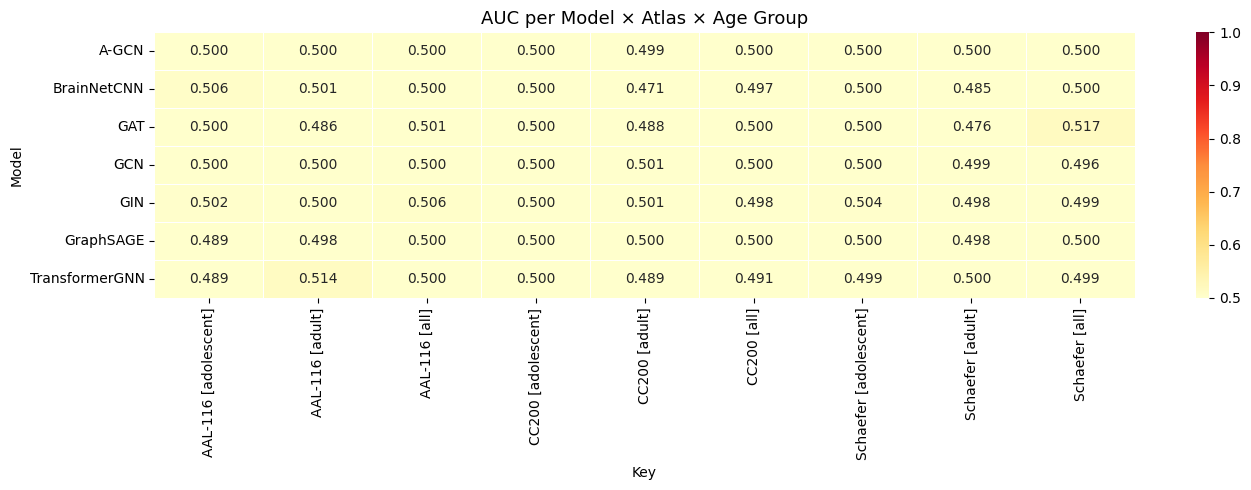

In [20]:
BEST = {}   # {(atlas, age_grp): (model_name, mean_auc, models_list)}
rows = []

for (atlas, age_grp, mname), r in ALL_RESULTS.items():
    mu_acc = np.mean(r["acc"]); sd_acc = np.std(r["acc"])
    mu_f1  = np.mean(r["f1"])
    mu_auc = np.mean(r["auc"]); sd_auc = np.std(r["auc"])
    rows.append({
        "Atlas": atlas, "AgeGroup": age_grp, "Model": mname,
        "Acc":   f"{mu_acc:.4f}±{sd_acc:.4f}",
        "F1":    f"{mu_f1:.4f}",
        "AUC":   f"{mu_auc:.4f}±{sd_auc:.4f}",
        "AUC_val": mu_auc,
    })
    key2 = (atlas, age_grp)
    if key2 not in BEST or mu_auc > BEST[key2][1]:
        BEST[key2] = (mname, mu_auc, ALL_MODELS[(atlas, age_grp, mname)])

result_df = pd.DataFrame(rows)
result_df.to_csv("./results_per_model.csv", index=False)

print("── Best model per (Atlas × Age Group) ──")
print(f"{'Atlas':12s}  {'AgeGroup':12s}  {'Best Model':18s}  {'AUC':>8}")
print("-"*56)
for (atlas, grp), (mname, auc, _) in sorted(BEST.items()):
    print(f"{atlas:12s}  {grp:12s}  {mname:18s}  {auc:.4f}")

# ── Heatmap: AUC per model × (atlas-agegroup) ────────────────────────────────
result_df["Key"] = result_df["Atlas"] + " [" + result_df["AgeGroup"] + "]"
pivot = result_df.pivot(index="Model", columns="Key", values="AUC_val")

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot.astype(float), annot=True, fmt=".3f",
            cmap="YlOrRd", vmin=0.5, vmax=1.0, ax=ax,
            linewidths=0.4, linecolor="white")
ax.set_title("AUC per Model × Atlas × Age Group", fontsize=13)
plt.tight_layout(); plt.show()


## Stage 11 — Cross-Atlas Fusion Model
**Architecture:**
- Best model per atlas × age group → frozen encoder → 64-dim embedding
- Cross-atlas attention gate → weighted concatenation
- SC-FC coupling scalars as auxiliary input
- MLP classifier trained end-to-end
- Separate fusion models for adolescent and adult groups


In [21]:
class CrossAtlasFusion(nn.Module):
    """
    Fuses embeddings from 3 atlases via attention gate.
    Input : list of 3 tensors (B, D_i)  +  couplings (B, 3)
    Output: logits (B, 2)
    """
    def __init__(self, embed_dims, n_atlases=3, num_classes=2, dropout=0.5):
        super().__init__()
        COMMON = 64
        # Project each atlas embedding to common dim
        self.projs = nn.ModuleList([
            nn.Sequential(nn.Linear(d, COMMON), nn.LayerNorm(COMMON), nn.ReLU())
            for d in embed_dims
        ])
        # Soft attention gate over atlases
        self.gate  = nn.Sequential(
            nn.Linear(COMMON * n_atlases, n_atlases), nn.Softmax(dim=1)
        )
        # Final classifier: weighted-sum concat + coupling scalars
        fuse_dim = COMMON * n_atlases + n_atlases
        self.clf = nn.Sequential(
            nn.Linear(fuse_dim, 256), nn.LayerNorm(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 64),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, embs, couplings):
        projected  = [proj(e) for proj, e in zip(self.projs, embs)]  # [(B,64),...]
        cat_proj   = torch.cat(projected, dim=1)                      # (B, 64*3)
        gates      = self.gate(cat_proj)                              # (B, 3)
        weighted   = torch.cat(
            [g.unsqueeze(1) * p for g, p in zip(gates.unbind(1), projected)],
            dim=1)                                                     # (B, 64*3)
        feat       = torch.cat([weighted, couplings], dim=1)
        return self.clf(feat)


def train_fusion(age_grp, atlases=("AAL-116","CC200","Schaefer"), epochs=100, patience=25):
    """Train and evaluate CrossAtlasFusion for one age group."""
    print(f"\n{'='*55}  Fusion [{age_grp}]")

    # ── Extract embeddings from best model per atlas ──────────────────────────
    emb_list, coup_list, y_ref, d_list = [], [], None, []
    for atlas in atlases:
        key2   = (atlas, age_grp)
        if key2 not in BEST:
            print(f"  ⚠️  No trained model for {atlas} [{age_grp}] — skipping fusion")
            return None, None
        _, _, mlist = BEST[key2]
        model  = mlist[-1]                       # last fold model
        ds     = DS[(atlas, age_grp)]
        loader = DataLoader(ds, batch_size=32, shuffle=False)
        embs, ys = extract_embeddings(model, loader)
        coup   = np.array([float(g.coupling.item()) for g in ds], dtype=np.float32)
        emb_list.append(embs); coup_list.append(torch.tensor(coup))
        d_list.append(embs.shape[1])
        if y_ref is None: y_ref = ys.numpy()

    # Align subject count
    min_n  = min(e.shape[0] for e in emb_list)
    emb_list   = [e[:min_n] for e in emb_list]
    coup_list  = [c[:min_n] for c in coup_list]
    y_ref      = y_ref[:min_n]
    couplings  = torch.stack(coup_list, dim=1)   # (N, 3)

    # ── 5-Fold CV on fusion MLP ───────────────────────────────────────────────
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    fuse_results = {"acc":[], "f1":[], "auc":[]}
    best_fusion  = None; best_auc = -1

    for fold, (tr, te) in enumerate(skf.split(np.arange(min_n), y_ref)):
        tr_set = TensorDataset(*[emb_list[i][tr] for i in range(3)],
                                couplings[tr],
                                torch.tensor(y_ref[tr], dtype=torch.long))
        te_set = TensorDataset(*[emb_list[i][te] for i in range(3)],
                                couplings[te],
                                torch.tensor(y_ref[te], dtype=torch.long))
        tr_ld  = TDL(tr_set, batch_size=32, shuffle=True)
        te_ld  = TDL(te_set, batch_size=32)

        fusion = CrossAtlasFusion(d_list).to(DEVICE)
        n_pos  = y_ref[tr].sum(); n_neg = len(tr) - n_pos
        w      = torch.tensor([n_pos/len(tr), n_neg/len(tr)],
                               dtype=torch.float32).to(DEVICE)
        crit   = nn.CrossEntropyLoss(weight=w)
        opt    = Adam(fusion.parameters(), lr=1e-3, weight_decay=1e-4)
        sched  = CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)

        best_a, best_st, no_imp = 0., None, 0
        for ep in range(1, epochs+1):
            fusion.train()
            for batch in tr_ld:
                e1,e2,e3,cp,y = [b.to(DEVICE) for b in batch]
                opt.zero_grad()
                loss = crit(fusion([e1,e2,e3], cp), y)
                loss.backward()
                nn.utils.clip_grad_norm_(fusion.parameters(), 2.0)
                opt.step()
            sched.step()
            # eval
            fusion.eval(); pa,ta,pra = [],[],[]
            with torch.no_grad():
                for batch in te_ld:
                    e1,e2,e3,cp,y = [b.to(DEVICE) for b in batch]
                    out = fusion([e1,e2,e3], cp)
                    pra.extend(F.softmax(out,1)[:,1].cpu().tolist())
                    pa.extend(out.argmax(1).cpu().tolist())
                    ta.extend(y.cpu().tolist())
            a = accuracy_score(ta, pa)
            if a > best_a:
                best_a  = a
                best_st = {k:v.clone() for k,v in fusion.state_dict().items()}
                no_imp  = 0
            else: no_imp += 1
            if no_imp >= patience: break

        fusion.load_state_dict(best_st)
        ta = np.array(ta); pa = np.array(pa); pra = np.nan_to_num(pra, nan=0.5)
        acc = accuracy_score(ta, pa)
        f1  = f1_score(ta, pa, average="macro", zero_division=0)
        auc = roc_auc_score(ta, pra) if len(np.unique(ta))>1 else 0.5
        fuse_results["acc"].append(acc)
        fuse_results["f1"].append(f1)
        fuse_results["auc"].append(auc)
        print(f"    Fold {fold+1}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
        if auc > best_auc: best_auc = auc; best_fusion = fusion

    mu = {k: np.mean(v) for k, v in fuse_results.items()}
    sd = {k: np.std(v)  for k, v in fuse_results.items()}
    print(f"    ── Mean  Acc={mu['acc']:.4f}±{sd['acc']:.4f}  "
          f"F1={mu['f1']:.4f}  AUC={mu['auc']:.4f}±{sd['auc']:.4f}")
    return fuse_results, best_fusion

# Train fusion for all, adolescent, adult
FUSION_RESULTS = {}
FUSION_MODELS  = {}
for grp in ["all", "adolescent", "adult"]:
    res, model = train_fusion(grp)
    if res is not None:
        FUSION_RESULTS[grp] = res
        FUSION_MODELS[grp]  = model



=======================================================  Fusion [all]
    Fold 1  Acc=0.5371  F1=0.3494  AUC=0.5000
    Fold 2  Acc=0.5345  F1=0.3483  AUC=0.5000
    Fold 3  Acc=0.5345  F1=0.3483  AUC=0.5000
    Fold 4  Acc=0.4598  F1=0.3150  AUC=0.5000
    Fold 5  Acc=0.5402  F1=0.3507  AUC=0.5000
    ── Mean  Acc=0.5212±0.0308  F1=0.3424  AUC=0.5000±0.0000

=======================================================  Fusion [adolescent]
    Fold 1  Acc=0.4732  F1=0.3212  AUC=0.5000
    Fold 2  Acc=0.5268  F1=0.3450  AUC=0.5000
    Fold 3  Acc=0.4685  F1=0.3190  AUC=0.5000
    Fold 4  Acc=0.4685  F1=0.3190  AUC=0.5000
    Fold 5  Acc=0.5315  F1=0.3471  AUC=0.5000
    ── Mean  Acc=0.4937±0.0290  F1=0.3303  AUC=0.5000±0.0000

=======================================================  Fusion [adult]
    Fold 1  Acc=0.4615  F1=0.3158  AUC=0.5000
    Fold 2  Acc=0.5385  F1=0.3500  AUC=0.5000
    Fold 3  Acc=0.5577  F1=0.3580  AUC=0.5000
    Fold 4  Acc=0.5490  F1=0.3544  AUC=0.5000
    Fold 5  

## Stage 12 — Grad-CAM: Adolescent vs Adult ROI Comparison

Computing Grad-CAM — adolescent ...
Computing Grad-CAM — adult ...


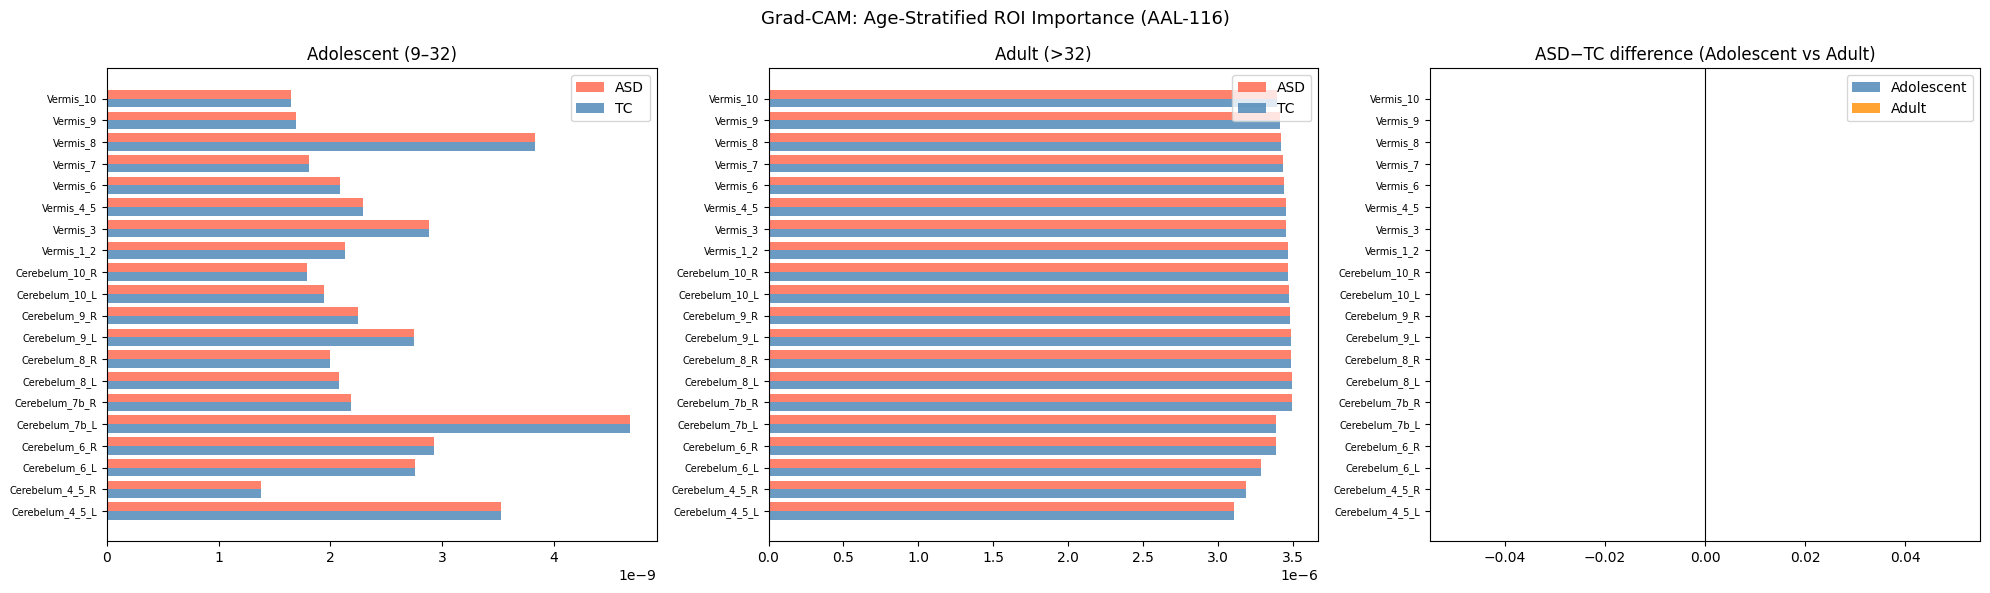

In [22]:
AAL_NAMES = [
    "Precentral_L","Precentral_R","Frontal_Sup_L","Frontal_Sup_R",
    "Frontal_Sup_Orb_L","Frontal_Sup_Orb_R","Frontal_Mid_L","Frontal_Mid_R",
    "Frontal_Mid_Orb_L","Frontal_Mid_Orb_R","Frontal_Inf_Oper_L","Frontal_Inf_Oper_R",
    "Frontal_Inf_Tri_L","Frontal_Inf_Tri_R","Frontal_Inf_Orb_L","Frontal_Inf_Orb_R",
    "Rolandic_Oper_L","Rolandic_Oper_R","Supp_Motor_Area_L","Supp_Motor_Area_R",
    "Olfactory_L","Olfactory_R","Frontal_Sup_Medial_L","Frontal_Sup_Medial_R",
    "Frontal_Med_Orb_L","Frontal_Med_Orb_R","Rectus_L","Rectus_R",
    "Insula_L","Insula_R","Cingulum_Ant_L","Cingulum_Ant_R",
    "Cingulum_Mid_L","Cingulum_Mid_R","Cingulum_Post_L","Cingulum_Post_R",
    "Hippocampus_L","Hippocampus_R","ParaHippocampal_L","ParaHippocampal_R",
    "Amygdala_L","Amygdala_R","Calcarine_L","Calcarine_R",
    "Cuneus_L","Cuneus_R","Lingual_L","Lingual_R",
    "Occipital_Sup_L","Occipital_Sup_R","Occipital_Mid_L","Occipital_Mid_R",
    "Occipital_Inf_L","Occipital_Inf_R","Fusiform_L","Fusiform_R",
    "Postcentral_L","Postcentral_R","Parietal_Sup_L","Parietal_Sup_R",
    "Parietal_Inf_L","Parietal_Inf_R","SupraMarginal_L","SupraMarginal_R",
    "Angular_L","Angular_R","Precuneus_L","Precuneus_R",
    "Paracentral_Lobule_L","Paracentral_Lobule_R","Caudate_L","Caudate_R",
    "Putamen_L","Putamen_R","Pallidum_L","Pallidum_R",
    "Thalamus_L","Thalamus_R","Heschl_L","Heschl_R",
    "Temporal_Sup_L","Temporal_Sup_R","Temporal_Pole_Sup_L","Temporal_Pole_Sup_R",
    "Temporal_Mid_L","Temporal_Mid_R","Temporal_Pole_Mid_L","Temporal_Pole_Mid_R",
    "Temporal_Inf_L","Temporal_Inf_R",
    "Cerebelum_Crus1_L","Cerebelum_Crus1_R","Cerebelum_Crus2_L","Cerebelum_Crus2_R",
    "Cerebelum_3_L","Cerebelum_3_R","Cerebelum_4_5_L","Cerebelum_4_5_R",
    "Cerebelum_6_L","Cerebelum_6_R","Cerebelum_7b_L","Cerebelum_7b_R",
    "Cerebelum_8_L","Cerebelum_8_R","Cerebelum_9_L","Cerebelum_9_R",
    "Cerebelum_10_L","Cerebelum_10_R","Vermis_1_2","Vermis_3",
    "Vermis_4_5","Vermis_6","Vermis_7","Vermis_8","Vermis_9","Vermis_10",
]

def node_saliency(model, graphs, n_rois, max_samples=100):
    """Gradient-based node importance (proxy Grad-CAM)."""
    model.eval()
    imp_asd = np.zeros(n_rois); imp_tc = np.zeros(n_rois)
    cnt_asd = cnt_tc = 0
    for g in graphs[:max_samples]:
        g2 = g.to(DEVICE)
        x  = g2.x.clone().detach().requires_grad_(True)
        b  = torch.zeros(x.shape[0], dtype=torch.long, device=DEVICE)
        d2 = Data(x=x, edge_index=g2.edge_index,
                  edge_attr=g2.edge_attr, y=g2.y, batch=b)
        out = model(d2)
        out[0, out.argmax().item()].backward()
        imp = x.grad.abs().mean(dim=1).detach().cpu().numpy()
        if int(g.y.item()) == 1: imp_asd += imp; cnt_asd += 1
        else:                     imp_tc  += imp; cnt_tc  += 1
    if cnt_asd: imp_asd /= cnt_asd
    if cnt_tc:  imp_tc  /= cnt_tc
    return imp_asd, imp_tc


# ── Run Grad-CAM for adolescent and adult AAL-116 best models ────────────────
key_adol  = ("AAL-116", "adolescent")
key_adult = ("AAL-116", "adult")

if key_adol in BEST and key_adult in BEST:
    m_adol  = BEST[key_adol][2][-1]
    m_adult = BEST[key_adult][2][-1]

    print("Computing Grad-CAM — adolescent ...")
    ia_a, it_a = node_saliency(m_adol,  DS[("AAL-116","adolescent")], 116)
    print("Computing Grad-CAM — adult ...")
    ia_d, it_d = node_saliency(m_adult, DS[("AAL-116","adult")],      116)

    diff_adol  = ia_a - it_a
    diff_adult = ia_d - it_d
    top20 = np.argsort(np.abs(diff_adol) + np.abs(diff_adult))[-20:][::-1]
    names = [AAL_NAMES[i] if i < len(AAL_NAMES) else f"ROI_{i}" for i in top20]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    x_pos = np.arange(20)

    # (a) Adolescent: ASD vs TC importance
    ax = axes[0]
    ax.barh(x_pos-0.2, ia_a[top20], 0.4, label="ASD", color="tomato",   alpha=0.8)
    ax.barh(x_pos+0.2, it_a[top20], 0.4, label="TC",  color="steelblue",alpha=0.8)
    ax.set_yticks(x_pos); ax.set_yticklabels(names, fontsize=7)
    ax.set_title("Adolescent (9–32)"); ax.legend(); ax.invert_yaxis()

    # (b) Adult: ASD vs TC importance
    ax = axes[1]
    ax.barh(x_pos-0.2, ia_d[top20], 0.4, label="ASD", color="tomato",   alpha=0.8)
    ax.barh(x_pos+0.2, it_d[top20], 0.4, label="TC",  color="steelblue",alpha=0.8)
    ax.set_yticks(x_pos); ax.set_yticklabels(names, fontsize=7)
    ax.set_title("Adult (>32)"); ax.legend(); ax.invert_yaxis()

    # (c) Adolescent vs Adult ASD-TC difference
    ax = axes[2]
    ax.barh(x_pos-0.2, diff_adol[top20],  0.4, label="Adolescent",color="steelblue",alpha=0.8)
    ax.barh(x_pos+0.2, diff_adult[top20], 0.4, label="Adult",     color="darkorange",alpha=0.8)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_yticks(x_pos); ax.set_yticklabels(names, fontsize=7)
    ax.set_title("ASD−TC difference (Adolescent vs Adult)")
    ax.legend(); ax.invert_yaxis()

    plt.suptitle("Grad-CAM: Age-Stratified ROI Importance (AAL-116)", fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print("⚠️  Adolescent or adult AAL models not found — run Stage 9 first")


## Stage 13 — Final Results Table & Model Save

In [24]:
summary_rows = []

# Per-model results
for (atlas, age_grp, mname), r in ALL_RESULTS.items():
    is_best = BEST.get((atlas, age_grp), (None,))[0] == mname
    summary_rows.append({
        "Atlas":    atlas,
        "AgeGroup": age_grp,
        "Model":    mname,
        "Acc":      f"{np.mean(r['acc']):.4f}±{np.std(r['acc']):.4f}",
        "F1":       f"{np.mean(r['f1']):.4f}",
        "AUC":      f"{np.mean(r['auc']):.4f}±{np.std(r['auc']):.4f}",
        "AUC_val":  np.mean(r["auc"]),
        "Best":     "★" if is_best else "",
    })

# Fusion results
for grp, r in FUSION_RESULTS.items():
    summary_rows.append({
        "Atlas":    "ALL (fusion)",
        "AgeGroup": grp,
        "Model":    "CrossAtlasFusion",
        "Acc":      f"{np.mean(r['acc']):.4f}±{np.std(r['acc']):.4f}",
        "F1":       f"{np.mean(r['f1']):.4f}",
        "AUC":      f"{np.mean(r['auc']):.4f}±{np.std(r['auc']):.4f}",
        "AUC_val":  np.mean(r["auc"]),
        "Best":     "★",
    })

final_df = pd.DataFrame(summary_rows)
final_df.to_csv("./results_final.csv", index=False)

# Print paper-ready table
print("="*90)
print("FINAL RESULTS  (copy → paper Table)")
print("="*90)
disp = final_df[["Atlas","AgeGroup","Model","Acc","F1","AUC","Best"]].copy()
print(disp.to_string(index=False))
print("="*90)
print("Saved: results_final.csv")

# Alpha summary (H3 hypothesis)
print("\n── Learned alpha values (A-GCN, SC-FC coupling weight) ──")
print(f"  α > 0.5 → FC-heavy (SC prior less effective)")
print(f"  α < 0.5 → SC-heavy (model relies on structural scaffold)")
print()
for atlas, age_grp, _ in TRAIN_REGISTRY:
    key = (atlas, age_grp, "A-GCN")
    if key in ALL_MODELS:
        alphas = [m.get_alpha() for m in ALL_MODELS[key] if hasattr(m,"get_alpha")]
        if alphas:
            print(f"  {atlas:12s} [{age_grp:11s}]  "
                  f"α={np.mean(alphas):.3f}±{np.std(alphas):.3f}")


FINAL RESULTS  (copy → paper Table)
       Atlas   AgeGroup            Model           Acc     F1           AUC Best
     AAL-116        all              GCN 0.5373±0.0026 0.3495 0.5000±0.0000     
     AAL-116        all              GAT 0.5373±0.0026 0.3495 0.5011±0.0071     
     AAL-116        all              GIN 0.5373±0.0026 0.3495 0.5058±0.0087    ★
     AAL-116        all            A-GCN 0.5373±0.0026 0.3495 0.5000±0.0000     
     AAL-116        all        GraphSAGE 0.5373±0.0026 0.3495 0.5000±0.0000     
     AAL-116        all      BrainNetCNN 0.5373±0.0026 0.3495 0.5000±0.0000     
     AAL-116        all   TransformerGNN 0.5373±0.0026 0.3495 0.5000±0.0000     
     AAL-116 adolescent              GCN 0.5296±0.0023 0.3462 0.5000±0.0000     
     AAL-116 adolescent              GAT 0.5296±0.0023 0.3462 0.5000±0.0000     
     AAL-116 adolescent              GIN 0.5296±0.0023 0.3462 0.5024±0.0347     
     AAL-116 adolescent            A-GCN 0.5296±0.0023 0.3462 0.5000±0.00

In [25]:
# ── Save best models ──────────────────────────────────────────────────────────
os.makedirs("./saved_models", exist_ok=True)

for (atlas, grp), (mname, auc, mlist) in BEST.items():
    fname = f"best_{atlas.replace('-','').lower()}_{grp}_{mname.lower()}.pt"
    path  = f"./saved_models/{fname}"
    torch.save(mlist[-1].state_dict(), path)
    print(f"  Saved: {fname}  (AUC={auc:.4f})")

for grp, model in FUSION_MODELS.items():
    if model is not None:
        path = f"./saved_models/fusion_{grp}.pt"
        torch.save(model.state_dict(), path)
        print(f"  Saved: fusion_{grp}.pt")

print("\n✅ Pipeline complete.")
print("   All results → ./results_final.csv")
print("   All models  → ./saved_models/")


  Saved: best_aal116_all_gin.pt  (AUC=0.5058)
  Saved: best_aal116_adolescent_brainnetcnn.pt  (AUC=0.5062)
  Saved: best_aal116_adult_transformergnn.pt  (AUC=0.5143)
  Saved: best_cc200_all_gcn.pt  (AUC=0.5000)
  Saved: best_cc200_adolescent_gin.pt  (AUC=0.5002)
  Saved: best_cc200_adult_gcn.pt  (AUC=0.5012)
  Saved: best_schaefer_all_gat.pt  (AUC=0.5175)
  Saved: best_schaefer_adolescent_gin.pt  (AUC=0.5035)
  Saved: best_schaefer_adult_a-gcn.pt  (AUC=0.5000)
  Saved: fusion_all.pt
  Saved: fusion_adolescent.pt
  Saved: fusion_adult.pt

✅ Pipeline complete.
   All results → ./results_final.csv
   All models  → ./saved_models/
